In [1]:
# ruff: noqa: F401

In [16]:
%load_ext autoreload
%load_ext pyinstrument
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from datetime import datetime
from typing import Any

import numpy as np
import polars as pl

from encomp.fluids import Fluid, Water
from encomp.misc import isinstance_types
from encomp.units import Quantity as Q
from encomp.units import Unit
from encomp.utypes import (
    DT,
    MT,
    Currency,
    Density,
    Dimensionality,
    Dimensionless,
    Length,
    Mass,
    Numpy1DArray,
    Power,
    Temperature,
    TemperatureDifference,
    Time,
    UnitsContainer,
    UnknownDimensionality,
)

In [18]:
pl.select(Fluid("IF97::Water", P=Q(pl.lit(25), "bar"), T=Q(pl.lit(25), "degC")).D.m)

D
f32
998.125427


In [19]:
N = 10_000_000

T,D
f64,f32
100.0,958.541016
100.00001,958.541016
100.00002,958.541016
100.00003,958.541016
100.00004,958.541016
…,…
199.99996,2.352755
199.99997,2.352755
199.99998,2.352755


_     ._   __/__   _ _  _  _ _/_   Recorded: 11:06:13  Samples:  3
 /_//_/// /_\ / //_// / //_'/ //     Duration: 3.123     CPU time: 3.122
/   _/                      v5.1.2

Cell [22]

3.123 <module>  /var/folders/wt/2s8cn3zn1nndhbq08y2cjm500000gn/T/ipykernel_63738/3963608110.py:1
`- 3.117 DataFrame.with_columns  polars/dataframe/frame.py:10506
      [3 frames hidden]  polars
         3.117 PyLazyFrame.collect  <built-in>
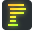

In [21]:
%%pyinstrument

w = Water(P=Q(pl.lit(5), "bar"), T=Q(pl.col.T, "degC"))

pl.DataFrame({"T": np.linspace(100, 200, N)}).with_columns(w.D.m)

array([958.54102553, 958.54101834, 958.54101115, ...,   2.35275492,
         2.35275486,   2.35275481], shape=(10000000,))

_     ._   __/__   _ _  _  _ _/_   Recorded: 11:06:38  Samples:  11
 /_//_/// /_\ / //_// / //_'/ //     Duration: 1.052     CPU time: 1.051
/   _/                      v5.1.2

Cell [24]

1.051 <module>  /var/folders/wt/2s8cn3zn1nndhbq08y2cjm500000gn/T/ipykernel_63738/555997269.py:1
`- 1.046 Water.D  encomp/fluids.py:1622
   `- 1.046 Water.get  encomp/fluids.py:1267
      `- 1.040 Water.evaluate  encomp/fluids.py:2
         `- 1.035 Water._rust_eager  encomp/fluids.py:975
            `- 1.029 DataFrame.select  polars/dataframe/frame.py:10385
                  [3 frames hidden]  polars
                     1.029 PyLazyFrame.collect  <built-in>
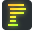

In [ ]:
# %%pyinstrument

w = Water(
    T=Q(np.linspace(100, 200, N), "degC"),
    P=Q(5, "bar"),
)

w.D.m

In [ ]:
repr(Water(P=Q(pl.lit(5), "bar"), T=Q(50, "degC")))

In [ ]:
pl.select(Water(P=Q(pl.lit(5), "bar"), T=Q(pl.lit(250), "degC")).D)

In [ ]:
pl.DataFrame({"T": [150, 200, 250]}).select((pl.col.T * 2).alias("asd"))